# How to train your model
---

This notebook trains EmberFlow from scratch on a small catalog of mock stars
so that you can see the full recipe and use it for your own catalog of rotators.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import zuko

from emberflow import EmberFlow
from emberflow.constants import P_OUT, PRIOR_LOGPROT
from emberflow.plots import COLOR, COLOR_ACCENT, LABEL_FS, TICK_FS, set_paper_style

set_paper_style()
rng = np.random.default_rng(0)
torch.manual_seed(0)

## A mock catalog of stars

We uniformly draw ages and masses to create our mock catalog, then sample one rotation period per star from
the released model. 

In [2]:
ref = EmberFlow.load()

n = 2000
mass = rng.uniform(0.15, 0.60, n)
age_gyr = 10 ** rng.uniform(np.log10(0.05), np.log10(10.0), n)
mass_err = np.full(n, 0.02)
prot = np.array([ref.sample_prot(age_gyr=a, mass=m, mass_err=e, n=1)[0]
                 for a, m, e in zip(age_gyr, mass, mass_err)])

cond = np.column_stack([np.log10(age_gyr * 1000), mass, mass_err]).astype("float32")
x = np.log10(prot).astype("float32").reshape(-1, 1)
print(cond.shape, x.shape)

(2000, 3) (2000, 1)


## Build and train the flow

The architecture is a neural spline flow with a single observable ($\log P_{\mathrm{rot}}$)
conditioned on three inputs.

 We minimize the EmberFlow loss (more details in the paper).

In [3]:
mean = cond.mean(0)
std = cond.std(0)
C = torch.tensor((cond - mean) / std)
X = torch.tensor(x)

flow = zuko.flows.NSF(1, 3, transforms=3, hidden_features=(64, 64, 64, 64))
opt = torch.optim.Adam(flow.parameters(), lr=1e-3)

ln_wf = float(np.log(1 - P_OUT))
ln_pout = float(np.log(P_OUT / (PRIOR_LOGPROT[1] - PRIOR_LOGPROT[0])))

losses = []
batch = 256
for epoch in range(300):
    perm = torch.randperm(len(X))
    for i in range(0, len(X), batch):
        idx = perm[i:i + batch]
        log_flow = flow(C[idx]).log_prob(X[idx])
        log_mix = torch.logaddexp(ln_wf + log_flow,
                                  torch.full_like(log_flow, ln_pout))
        loss = -log_mix.mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    losses.append(loss.item())

flow.eval()

NSF(
  (transform): LazyComposedTransform(
    (0-2): 3 x ElementWiseTransform(
      (base): MonotonicRQSTransform(bins=8)
      (hyper): MLP(
        (0): Linear(in_features=3, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=64, bias=True)
        (5): ReLU()
        (6): Linear(in_features=64, out_features=64, bias=True)
        (7): ReLU()
        (8): Linear(in_features=64, out_features=23, bias=True)
      )
    )
  )
  (base): UnconditionalDistribution(DiagNormal(loc: tensor([0.]), scale: tensor([1.])))
)

## Using the trained model

The trained flow works with the `EmberFlow` API, so we can use its functions for convenience.

In [4]:
card = {
    "cond_cols": ["log_age_myr", "mass_msun", "mass_msun_err_avg"],
    "transforms": 3,
    "hidden_features": [64, 64, 64, 64],
    "training_range": {
        "mass_msun": [float(mass.min()), float(mass.max())],
        "prot_days": [float(prot.min()), float(prot.max())],
        "age_gyr": [float(age_gyr.min()), float(age_gyr.max())],
    },
}
model = EmberFlow(flow, mean, std, card)

post = model.age_posterior(prot=25.0, mass=0.45, mass_err=0.02)
print(post)

AgePosterior(1.85 -0.66/+2.14 Gyr, 68%)


Let's see how well the learned density of this new model compares with the mock periods (which came from the released model).

Text(0.5, 1.0, '$M_\\star$ = 0.50 $M_\\odot$,  age = 1 Gyr')

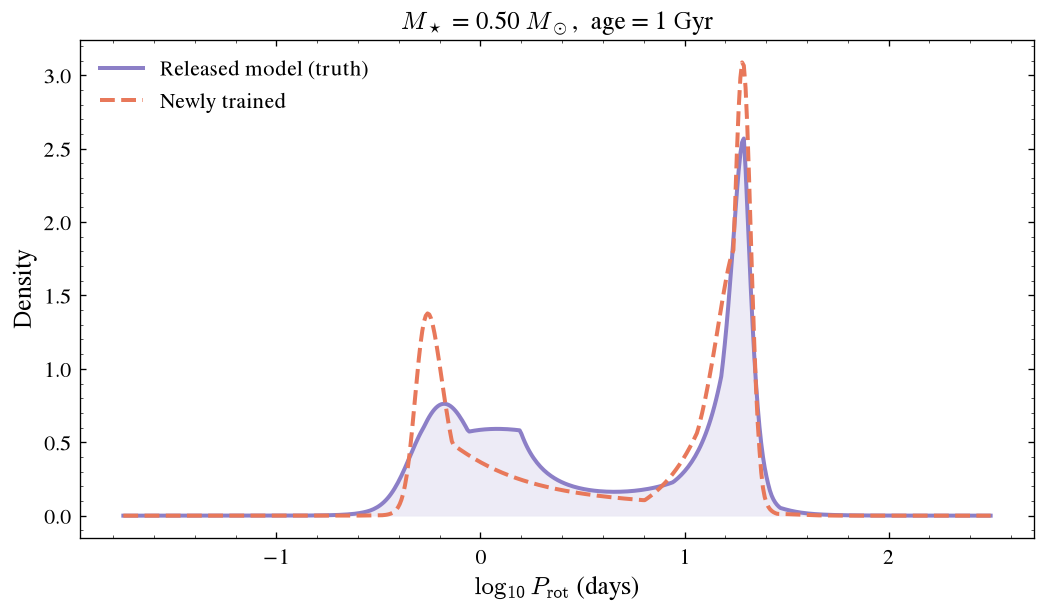

In [5]:
grid, pdf_new = model.prot_density(age_gyr=1.0, mass=0.50, mass_err=0.02)
_, pdf_ref = ref.prot_density(age_gyr=1.0, mass=0.50, mass_err=0.02)

fig, ax = plt.subplots(figsize=(8.6, 5.0), layout="constrained")
ax.fill_between(grid, pdf_ref, color=COLOR, alpha=0.15)
ax.plot(grid, pdf_ref, color=COLOR, lw=2.4, label="Released model (truth)")
ax.plot(grid, pdf_new, color=COLOR_ACCENT, lw=2.4, ls="--", label="Newly trained")
ax.set_xlabel(r"$\log_{10} P_{\rm rot}$ (days)", fontsize=LABEL_FS)
ax.set_ylabel("Density", fontsize=LABEL_FS)
ax.tick_params(labelsize=TICK_FS)
ax.legend(frameon=False, fontsize=TICK_FS)
ax.set_title(r"$M_\star$ = 0.50 $M_\odot$,  age = 1 Gyr", fontsize=LABEL_FS)